<a href="https://colab.research.google.com/github/andergibran/solid-waddle/blob/main/Tugas_Kecil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Klasifikasi Rekomendasi Tanaman Berdasarkan Kondisi Tanah dan Iklim

## Deskripsi Proyek
Proyek ini membangun model Machine Learning untuk merekomendasikan
jenis tanaman yang paling cocok ditanam berdasarkan kondisi tanah
dan iklim suatu lahan.

## Sumber Dataset
- **Nama**: Crop Recommendation Dataset
- **Sumber**: Kaggle
- **Link**: https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset
- **Jumlah data**: 2.200 baris
- **Jumlah fitur**: 7 fitur input + 1 kolom target
- **Jumlah kelas**: 22 jenis tanaman

## Deskripsi Fitur
| Fitur | Deskripsi |
|---|---|
| N | Kadar Nitrogen dalam tanah |
| P | Kadar Fosfor dalam tanah |
| K | Kadar Kalium dalam tanah |
| temperature | Suhu udara (°C) |
| humidity | Kelembapan udara (%) |
| ph | Tingkat keasaman tanah |
| rainfall | Curah hujan (mm) |
| label | Jenis tanaman (TARGET) |

## Algoritma yang Digunakan
1. Random Forest
2. Naive Bayes
3. Support Vector Machine (SVM)

# Data Understanding

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Crop_recommendation.csv to Crop_recommendation.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Library berhasil diimport!")

Library berhasil diimport!


In [4]:
df = pd.read_csv('Crop_recommendation.csv')

print("Dataset berhasil dimuat!")
print(f"\nJumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print(f"\n5 data pertama:")
df.head()

Dataset berhasil dimuat!

Jumlah baris: 2200
Jumlah kolom: 8

5 data pertama:


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [5]:
print("=== INFO DATASET ===")
df.info()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [6]:
print("=== STATISTIK DESKRIPTIF ===")
df.describe()

=== STATISTIK DESKRIPTIF ===


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [7]:
print("=== MISSING VALUES ===")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

=== MISSING VALUES ===
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Total missing values: 0


In [8]:
print("=== DATA DUPLIKAT ===")
print(f"Jumlah duplikat: {df.duplicated().sum()}")

=== DATA DUPLIKAT ===
Jumlah duplikat: 0


In [9]:
print("=== DISTRIBUSI KELAS ===")
print(df['label'].value_counts())
print(f"\nJumlah kelas: {df['label'].nunique()}")

=== DISTRIBUSI KELAS ===
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

Jumlah kelas: 22


In [10]:
print("=== DAFTAR KELAS TANAMAN ===")
for i, crop in enumerate(sorted(df['label'].unique()), 1):
    print(f"{i}. {crop}")

=== DAFTAR KELAS TANAMAN ===
1. apple
2. banana
3. blackgram
4. chickpea
5. coconut
6. coffee
7. cotton
8. grapes
9. jute
10. kidneybeans
11. lentil
12. maize
13. mango
14. mothbeans
15. mungbean
16. muskmelon
17. orange
18. papaya
19. pigeonpeas
20. pomegranate
21. rice
22. watermelon


# Data Preprocessing

In [11]:
print("=== DROP DUPLIKAT ===")
df = df.drop_duplicates()
print(f"Jumlah data setelah drop duplikat: {len(df)}")

=== DROP DUPLIKAT ===
Jumlah data setelah drop duplikat: 2200


In [12]:
print("=== CEK OUTLIER (IQR) ===")
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outlier ({len(outliers)/len(df)*100:.1f}%)")

=== CEK OUTLIER (IQR) ===
N: 0 outlier (0.0%)
P: 138 outlier (6.3%)
K: 200 outlier (9.1%)
temperature: 86 outlier (3.9%)
humidity: 30 outlier (1.4%)
ph: 57 outlier (2.6%)
rainfall: 100 outlier (4.5%)


In [13]:
print("=== PENANGANAN OUTLIER ===")
# Outlier tidak dihapus karena nilai masih valid secara agronomi
# Contoh: tanaman apple memang butuh K sangat tinggi (rata-rata 200)
print(f"Jumlah data sebelum penanganan outlier: {len(df)}")
print(f"Jumlah data setelah penanganan outlier: {len(df)}")
print("Keputusan: Outlier dipertahankan karena valid secara agronomi")

=== PENANGANAN OUTLIER ===
Jumlah data sebelum penanganan outlier: 2200
Jumlah data setelah penanganan outlier: 2200
Keputusan: Outlier dipertahankan karena valid secara agronomi


In [14]:
print("=== PISAHKAN FITUR DAN LABEL ===")
X = df.drop('label', axis=1)
y = df['label']

print(f"Shape fitur (X): {X.shape}")
print(f"Shape label (y): {y.shape}")
print(f"\nFitur yang digunakan: {list(X.columns)}")

=== PISAHKAN FITUR DAN LABEL ===
Shape fitur (X): (2200, 7)
Shape label (y): (2200,)

Fitur yang digunakan: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']


In [15]:
from sklearn.preprocessing import LabelEncoder

print("=== ENCODING LABEL ===")
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Contoh label asli : {list(y[:5])}")
print(f"Contoh label encoded: {list(y_encoded[:5])}")
print(f"\nMapping kelas:")
for i, kelas in enumerate(le.classes_):
    print(f"  {i} = {kelas}")

=== ENCODING LABEL ===
Contoh label asli : ['rice', 'rice', 'rice', 'rice', 'rice']
Contoh label encoded: [np.int64(20), np.int64(20), np.int64(20), np.int64(20), np.int64(20)]

Mapping kelas:
  0 = apple
  1 = banana
  2 = blackgram
  3 = chickpea
  4 = coconut
  5 = coffee
  6 = cotton
  7 = grapes
  8 = jute
  9 = kidneybeans
  10 = lentil
  11 = maize
  12 = mango
  13 = mothbeans
  14 = mungbean
  15 = muskmelon
  16 = orange
  17 = papaya
  18 = pigeonpeas
  19 = pomegranate
  20 = rice
  21 = watermelon


# EDA (Exploratory Data Analysis)

=== DISTRIBUSI KELAS TANAMAN ===


/tmp/ipykernel_9822/546286449.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', order=df['label'].value_counts().index, palette='viridis')


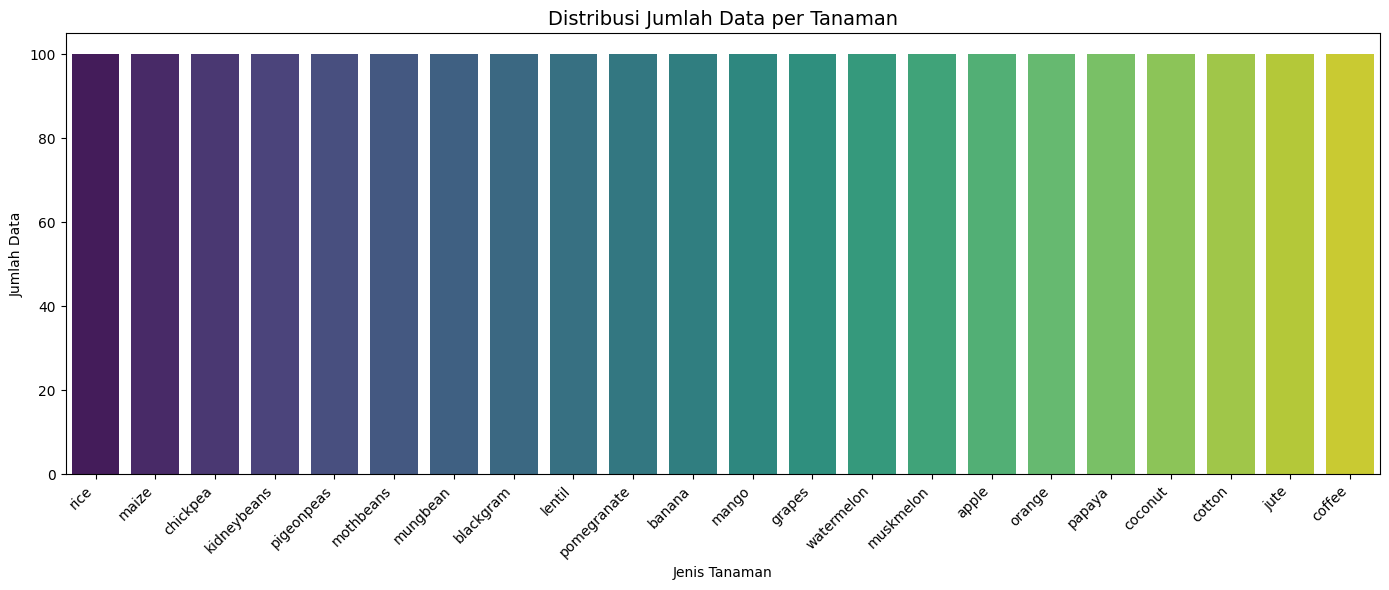

In [16]:
print("=== DISTRIBUSI KELAS TANAMAN ===")
plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index, palette='viridis')
plt.title('Distribusi Jumlah Data per Tanaman', fontsize=14)
plt.xlabel('Jenis Tanaman')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

=== HEATMAP KORELASI ANTAR FITUR ===


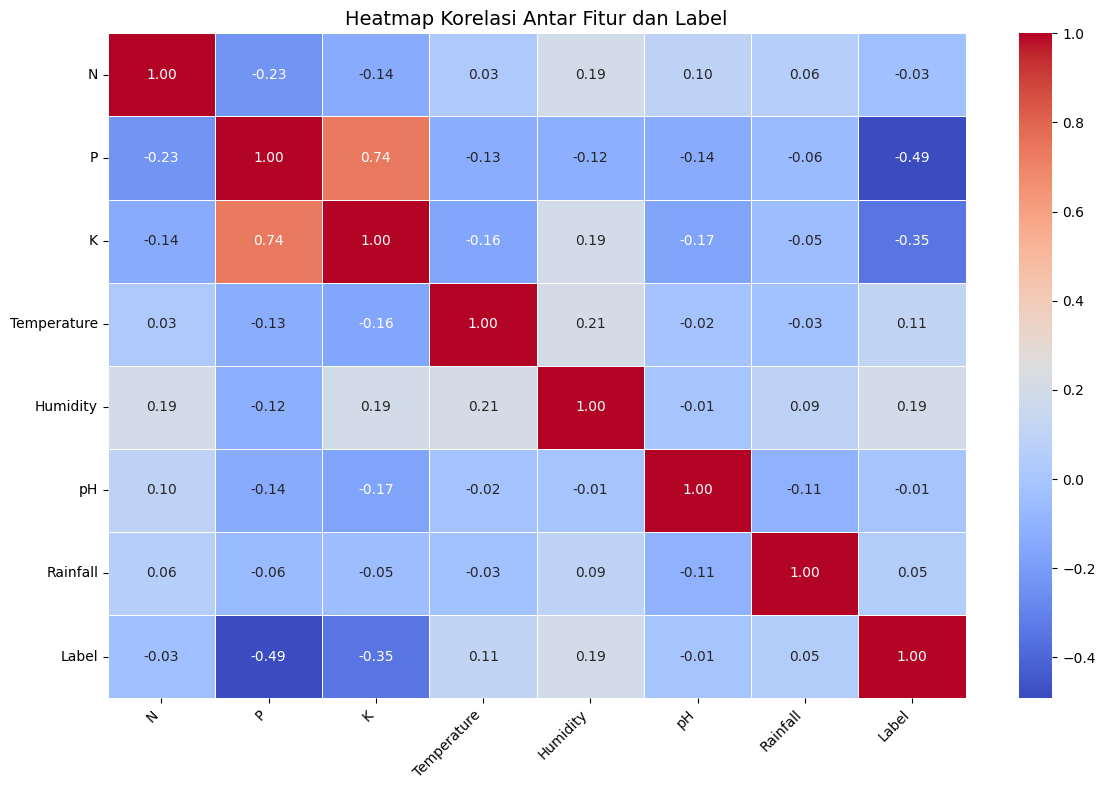

In [17]:
print("=== HEATMAP KORELASI ANTAR FITUR ===")

# Gabungkan fitur + label encoded
df_corr = X.copy()
df_corr['label'] = y_encoded

plt.figure(figsize=(12, 8))
sns.heatmap(df_corr.corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            xticklabels=['N', 'P', 'K', 'Temperature', 'Humidity', 'pH', 'Rainfall', 'Label'],
            yticklabels=['N', 'P', 'K', 'Temperature', 'Humidity', 'pH', 'Rainfall', 'Label'])
plt.title('Heatmap Korelasi Antar Fitur dan Label', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

=== BOXPLOT TIAP FITUR ===


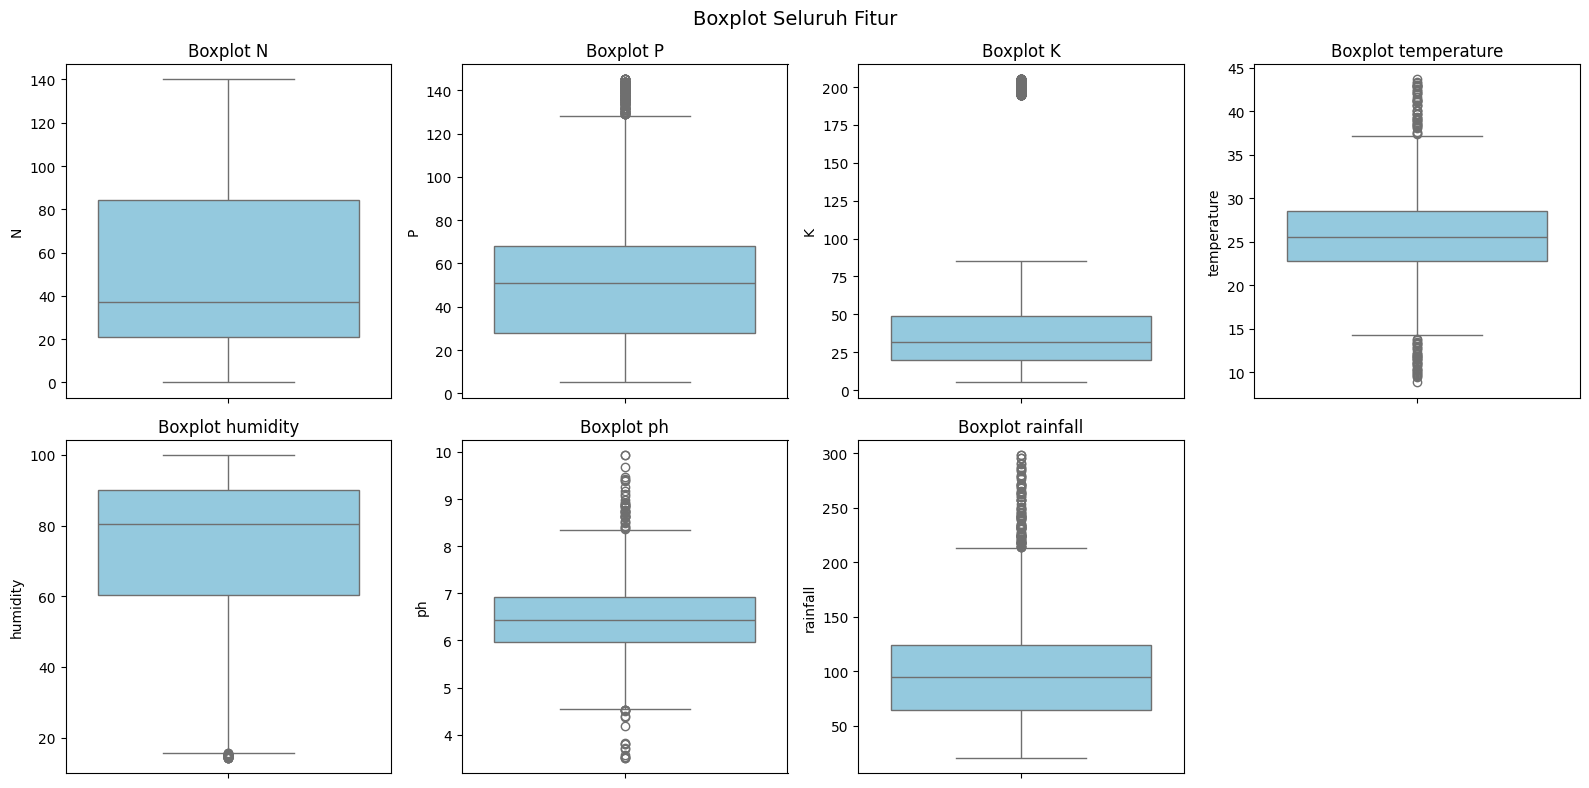

In [18]:
print("=== BOXPLOT TIAP FITUR ===")
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df, y=col, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot {col}')
    axes[i].set_ylabel(col)

axes[-1].set_visible(False)
plt.suptitle('Boxplot Seluruh Fitur', fontsize=14)
plt.tight_layout()
plt.show()

=== DISTRIBUSI TIAP FITUR ===


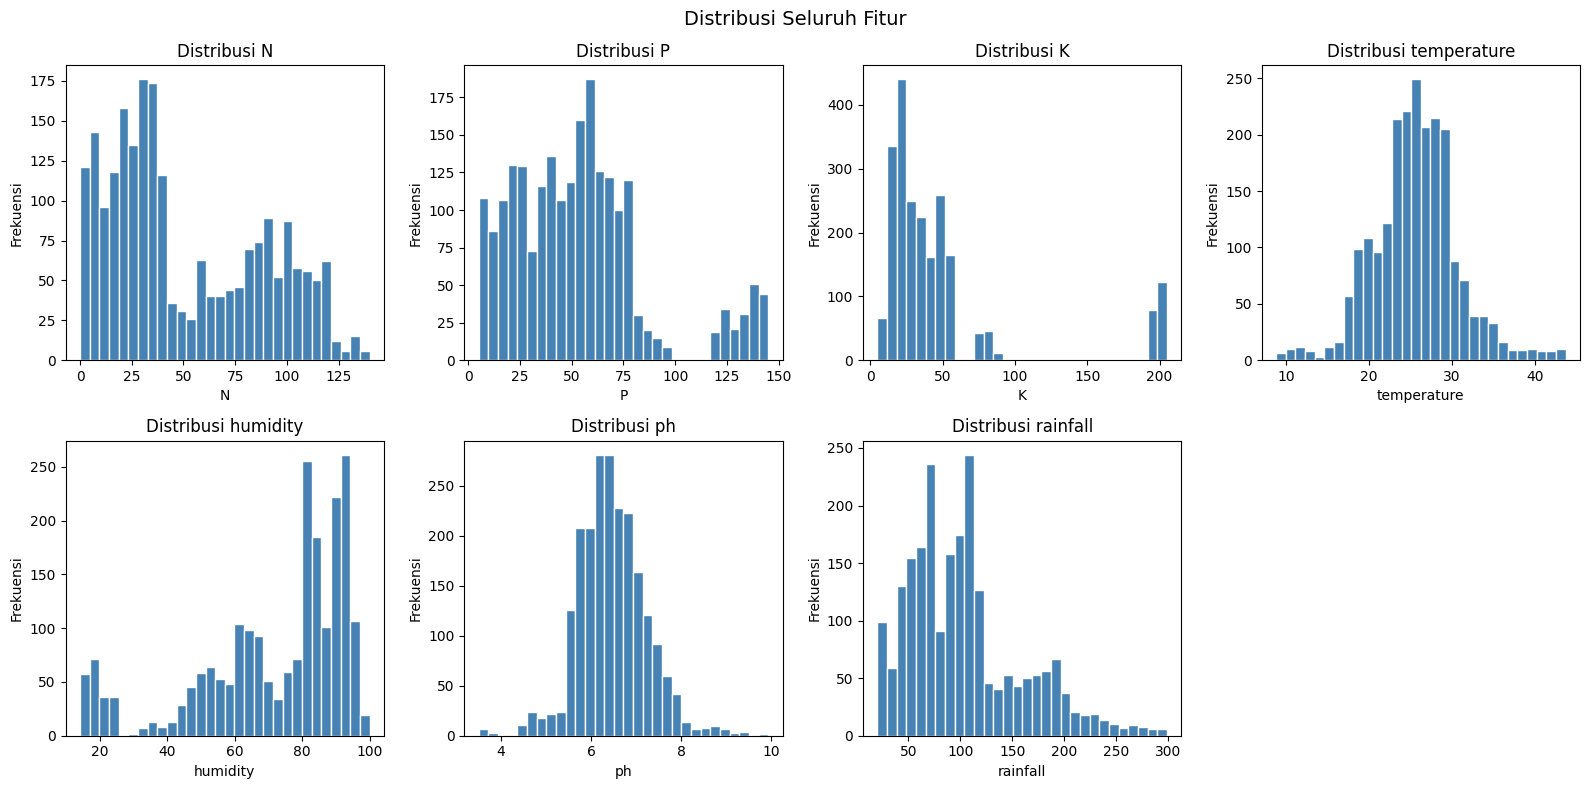

In [19]:
print("=== DISTRIBUSI TIAP FITUR ===")
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

axes[-1].set_visible(False)
plt.suptitle('Distribusi Seluruh Fitur', fontsize=14)
plt.tight_layout()
plt.show()

=== RATA-RATA FITUR PER TANAMAN ===


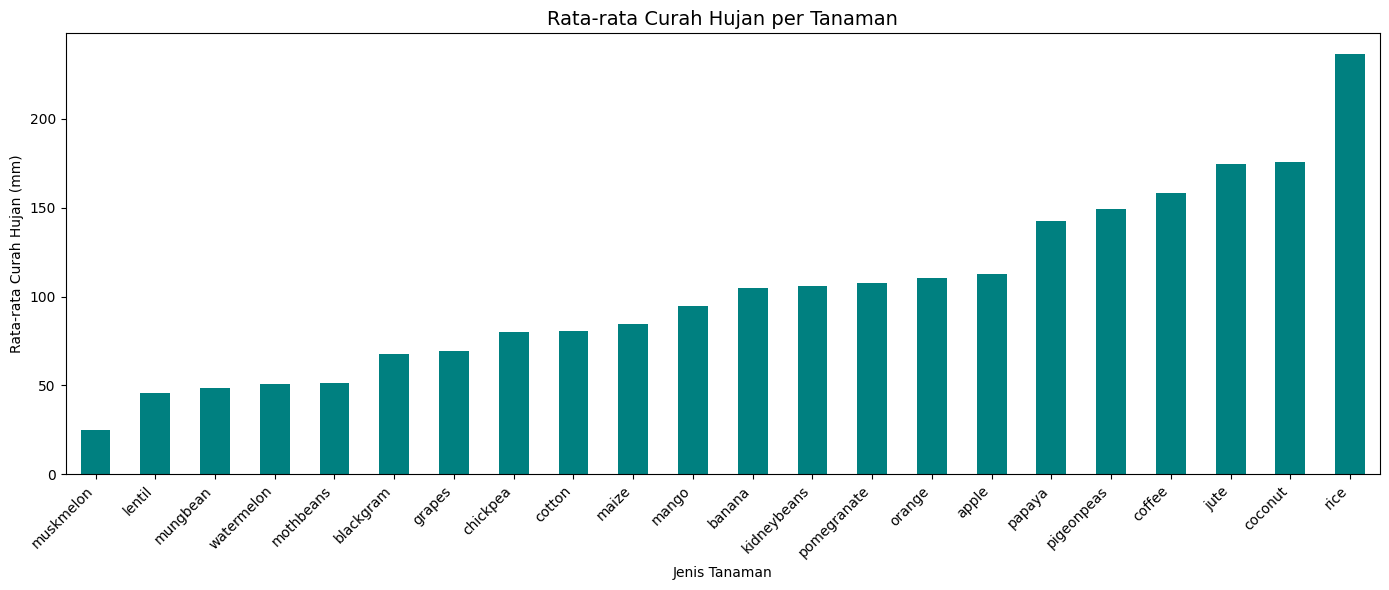

In [20]:
print("=== RATA-RATA FITUR PER TANAMAN ===")
plt.figure(figsize=(14, 6))
df.groupby('label')['rainfall'].mean().sort_values().plot(kind='bar', color='teal')
plt.title('Rata-rata Curah Hujan per Tanaman', fontsize=14)
plt.xlabel('Jenis Tanaman')
plt.ylabel('Rata-rata Curah Hujan (mm)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Data Splitting

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("=== DATA SPLITTING ===")

# ===== 70:30 =====
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

scaler_70 = StandardScaler()
X_train_70 = scaler_70.fit_transform(X_train_70)
X_test_70 = scaler_70.transform(X_test_70)


# ===== 80:20 =====
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

scaler_80 = StandardScaler()
X_train_80 = scaler_80.fit_transform(X_train_80)
X_test_80 = scaler_80.transform(X_test_80)


# ===== 90:10 =====
X_train_90, X_test_90, y_train_90, y_test_90 = train_test_split(
    X, y_encoded, test_size=0.1, random_state=42, stratify=y_encoded)

scaler_90 = StandardScaler()
X_train_90 = scaler_90.fit_transform(X_train_90)
X_test_90 = scaler_90.transform(X_test_90)


print(f"Split 70:30 → Training: {len(X_train_70)}, Testing: {len(X_test_70)}")
print(f"Split 80:20 → Training: {len(X_train_80)}, Testing: {len(X_test_80)}")
print(f"Split 90:10 → Training: {len(X_train_90)}, Testing: {len(X_test_90)}")

=== DATA SPLITTING ===
Split 70:30 → Training: 1540, Testing: 660
Split 80:20 → Training: 1760, Testing: 440
Split 90:10 → Training: 1980, Testing: 220


# Model Building

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Library model berhasil diimport!")

Library model berhasil diimport!


In [23]:
def train_evaluate(X_train, X_test, y_train, y_test, split_name):
    results = {}

    # Random Forest
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)
    rf_acc = accuracy_score(y_test, rf_pred)

    # Naive Bayes
    nb = GaussianNB()
    nb.fit(X_train, y_train)
    nb_pred = nb.predict(X_test)
    nb_acc = accuracy_score(y_test, nb_pred)

    # SVM
    svm = SVC(random_state=42)
    svm.fit(X_train, y_train)
    svm_pred = svm.predict(X_test)
    svm_acc = accuracy_score(y_test, svm_pred)

    print(f"\n=== HASIL SPLIT {split_name} ===")
    print(f"Random Forest : {rf_acc*100:.2f}%")
    print(f"Naive Bayes   : {nb_acc*100:.2f}%")
    print(f"SVM           : {svm_acc*100:.2f}%")

    results = {
        'RF': (rf, rf_pred, rf_acc),
        'NB': (nb, nb_pred, nb_acc),
        'SVM': (svm, svm_pred, svm_acc)
    }
    return results

print("Fungsi berhasil didefinisikan!")

Fungsi berhasil didefinisikan!


In [24]:
print("=== TRAINING SEMUA MODEL ===")


results_70 = train_evaluate(X_train_70, X_test_70, y_train_70, y_test_70, "70:30")
results_80 = train_evaluate(X_train_80, X_test_80, y_train_80, y_test_80, "80:20")
results_90 = train_evaluate(X_train_90, X_test_90, y_train_90, y_test_90, "90:10")

print("\n✅ Semua model berhasil ditraining!")

=== TRAINING SEMUA MODEL ===

=== HASIL SPLIT 70:30 ===
Random Forest : 99.39%
Naive Bayes   : 99.24%
SVM           : 98.94%

=== HASIL SPLIT 80:20 ===
Random Forest : 99.55%
Naive Bayes   : 99.55%
SVM           : 98.41%

=== HASIL SPLIT 90:10 ===
Random Forest : 99.09%
Naive Bayes   : 99.55%
SVM           : 99.55%

✅ Semua model berhasil ditraining!


# Hyperparameter Tuning

In [25]:
from sklearn.model_selection import GridSearchCV

print("=== TUNING RANDOM FOREST ===")


rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train_80, y_train_80)

print(f"Parameter terbaik RF: {rf_grid.best_params_}")
print(f"Akurasi terbaik RF  : {rf_grid.best_score_*100:.2f}%")

=== TUNING RANDOM FOREST ===
Parameter terbaik RF: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Akurasi terbaik RF  : 99.60%


In [26]:
print("=== TUNING NAIVE BAYES ===")

nb_params = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

nb_grid = GridSearchCV(
    GaussianNB(),
    nb_params, cv=5, scoring='accuracy', n_jobs=-1)
nb_grid.fit(X_train_80, y_train_80)

print(f"Parameter terbaik NB: {nb_grid.best_params_}")
print(f"Akurasi terbaik NB  : {nb_grid.best_score_*100:.2f}%")

=== TUNING NAIVE BAYES ===
Parameter terbaik NB: {'var_smoothing': 1e-09}
Akurasi terbaik NB  : 99.43%


In [27]:
print("=== TUNING SVM ===")


svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(
    SVC(random_state=42),
    svm_params, cv=5, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train_80, y_train_80)

print(f"Parameter terbaik SVM: {svm_grid.best_params_}")
print(f"Akurasi terbaik SVM  : {svm_grid.best_score_*100:.2f}%")

=== TUNING SVM ===
Parameter terbaik SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Akurasi terbaik SVM  : 98.52%


In [28]:
print("=== EVALUASI SETELAH TUNING (Split 80:20) ===")

# Model terbaik hasil tuning
rf_tuned = rf_grid.best_estimator_
nb_tuned = nb_grid.best_estimator_
svm_tuned = svm_grid.best_estimator_

# Prediksi
rf_tuned_pred = rf_tuned.predict(X_test_80)
nb_tuned_pred = nb_tuned.predict(X_test_80)
svm_tuned_pred = svm_tuned.predict(X_test_80)

# Akurasi setelah tuning
rf_tuned_acc = accuracy_score(y_test_80, rf_tuned_pred)
nb_tuned_acc = accuracy_score(y_test_80, nb_tuned_pred)
svm_tuned_acc = accuracy_score(y_test_80, svm_tuned_pred)

print(f"Random Forest : {rf_tuned_acc*100:.2f}%")
print(f"Naive Bayes   : {nb_tuned_acc*100:.2f}%")
print(f"SVM           : {svm_tuned_acc*100:.2f}%")

print("\n=== PERBANDINGAN SEBELUM VS SESUDAH TUNING ===")
print(f"{'Algoritma':<15} {'Sebelum':>10} {'Sesudah':>10} {'Perubahan':>10}")
print("-" * 50)

for algo, before, after in [
    ('Random Forest', results_80['RF'][2]*100, rf_tuned_acc*100),
    ('Naive Bayes',   results_80['NB'][2]*100, nb_tuned_acc*100),
    ('SVM',           results_80['SVM'][2]*100, svm_tuned_acc*100)
]:
    change = after - before
    symbol = "↑" if change > 0 else "↔" if change == 0 else "↓"
    print(f"{algo:<15} {before:>9.2f}% {after:>9.2f}% {symbol}{abs(change):>8.2f}%")

=== EVALUASI SETELAH TUNING (Split 80:20) ===
Random Forest : 99.55%
Naive Bayes   : 99.55%
SVM           : 98.86%

=== PERBANDINGAN SEBELUM VS SESUDAH TUNING ===
Algoritma          Sebelum    Sesudah  Perubahan
--------------------------------------------------
Random Forest       99.55%     99.55% ↔    0.00%
Naive Bayes         99.55%     99.55% ↔    0.00%
SVM                 98.41%     98.86% ↑    0.45%


# Evaluasi lengkap + Confusion Matrix

In [29]:
print("=== CLASSIFICATION REPORT RANDOM FOREST ===")
print(classification_report(y_test_80, rf_tuned_pred, target_names=le.classes_))

=== CLASSIFICATION REPORT RANDOM FOREST ===
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00    

In [30]:
print("=== CLASSIFICATION REPORT NAIVE BAYES ===")
print(classification_report(y_test_80, nb_tuned_pred, target_names=le.classes_))

=== CLASSIFICATION REPORT NAIVE BAYES ===
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.91      1.00      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      

In [31]:
print("=== CLASSIFICATION REPORT SVM ===")
print(classification_report(y_test_80, svm_tuned_pred, target_names=le.classes_))

=== CLASSIFICATION REPORT SVM ===
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.91      1.00      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       1.00      0.95      0.97        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.91      1.00      0.95        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00    

=== CONFUSION MATRIX RANDOM FOREST ===


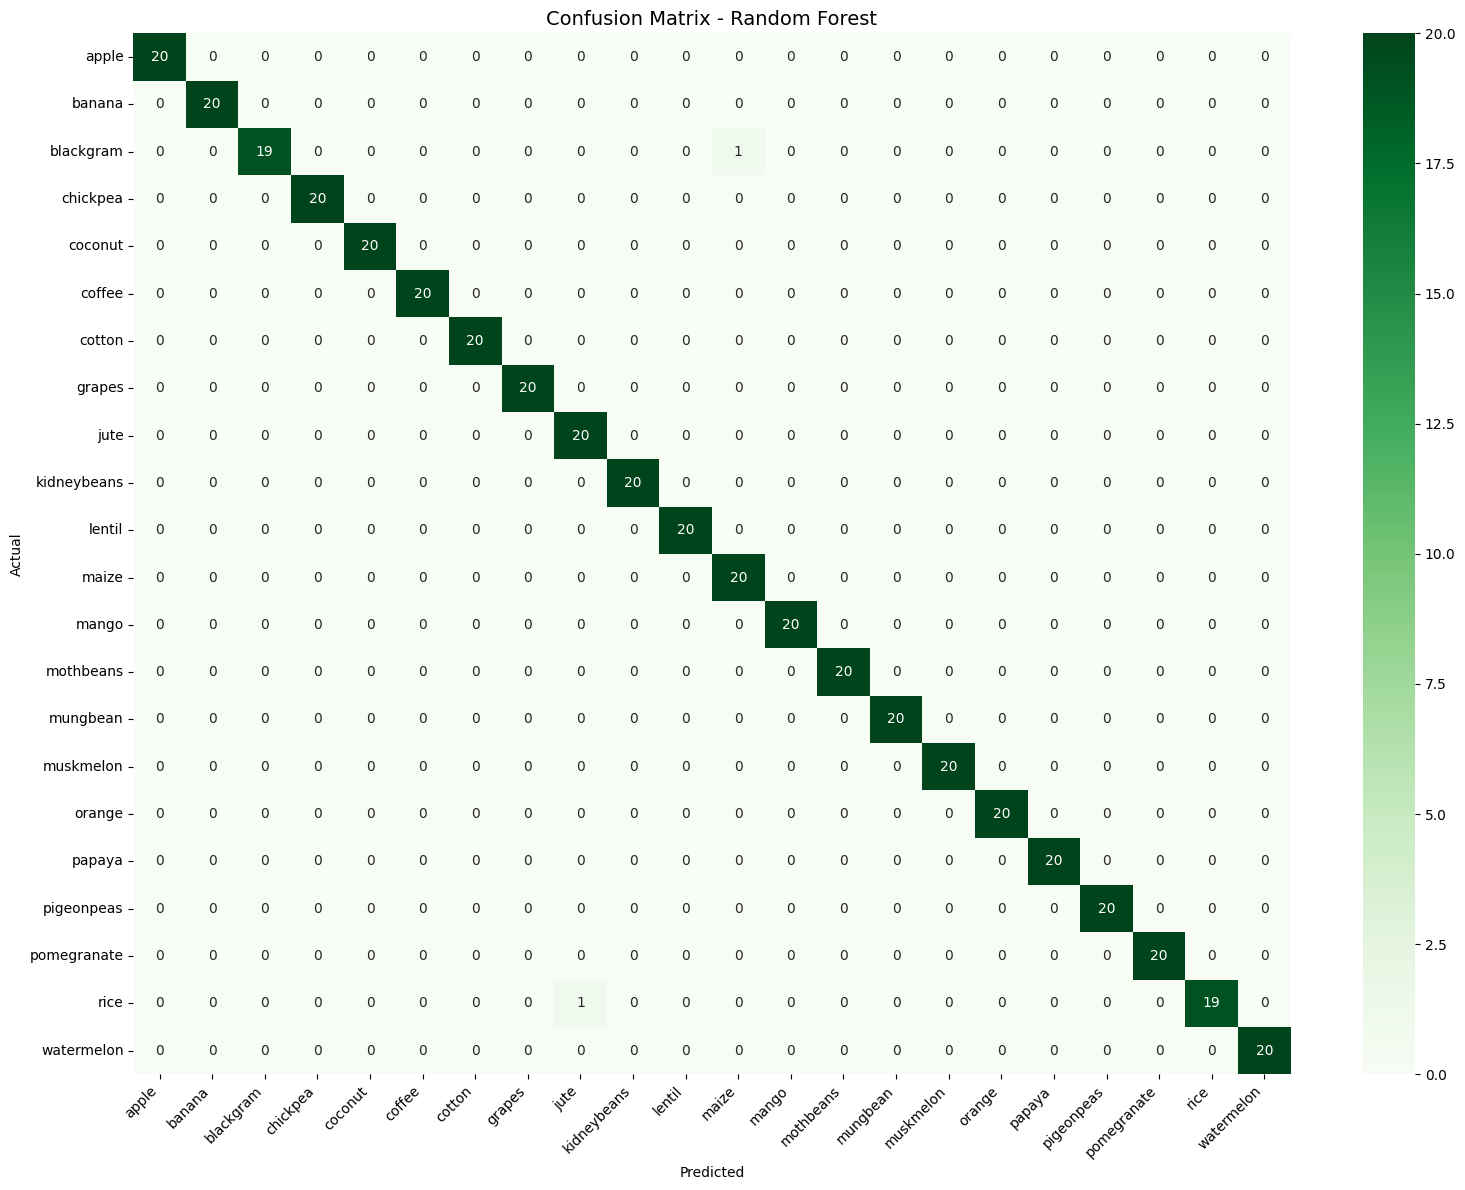

In [32]:
print("=== CONFUSION MATRIX RANDOM FOREST ===")
plt.figure(figsize=(16, 12))
cm_rf = confusion_matrix(y_test_80, rf_tuned_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Random Forest', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

=== CONFUSION MATRIX NAIVE BAYES ===


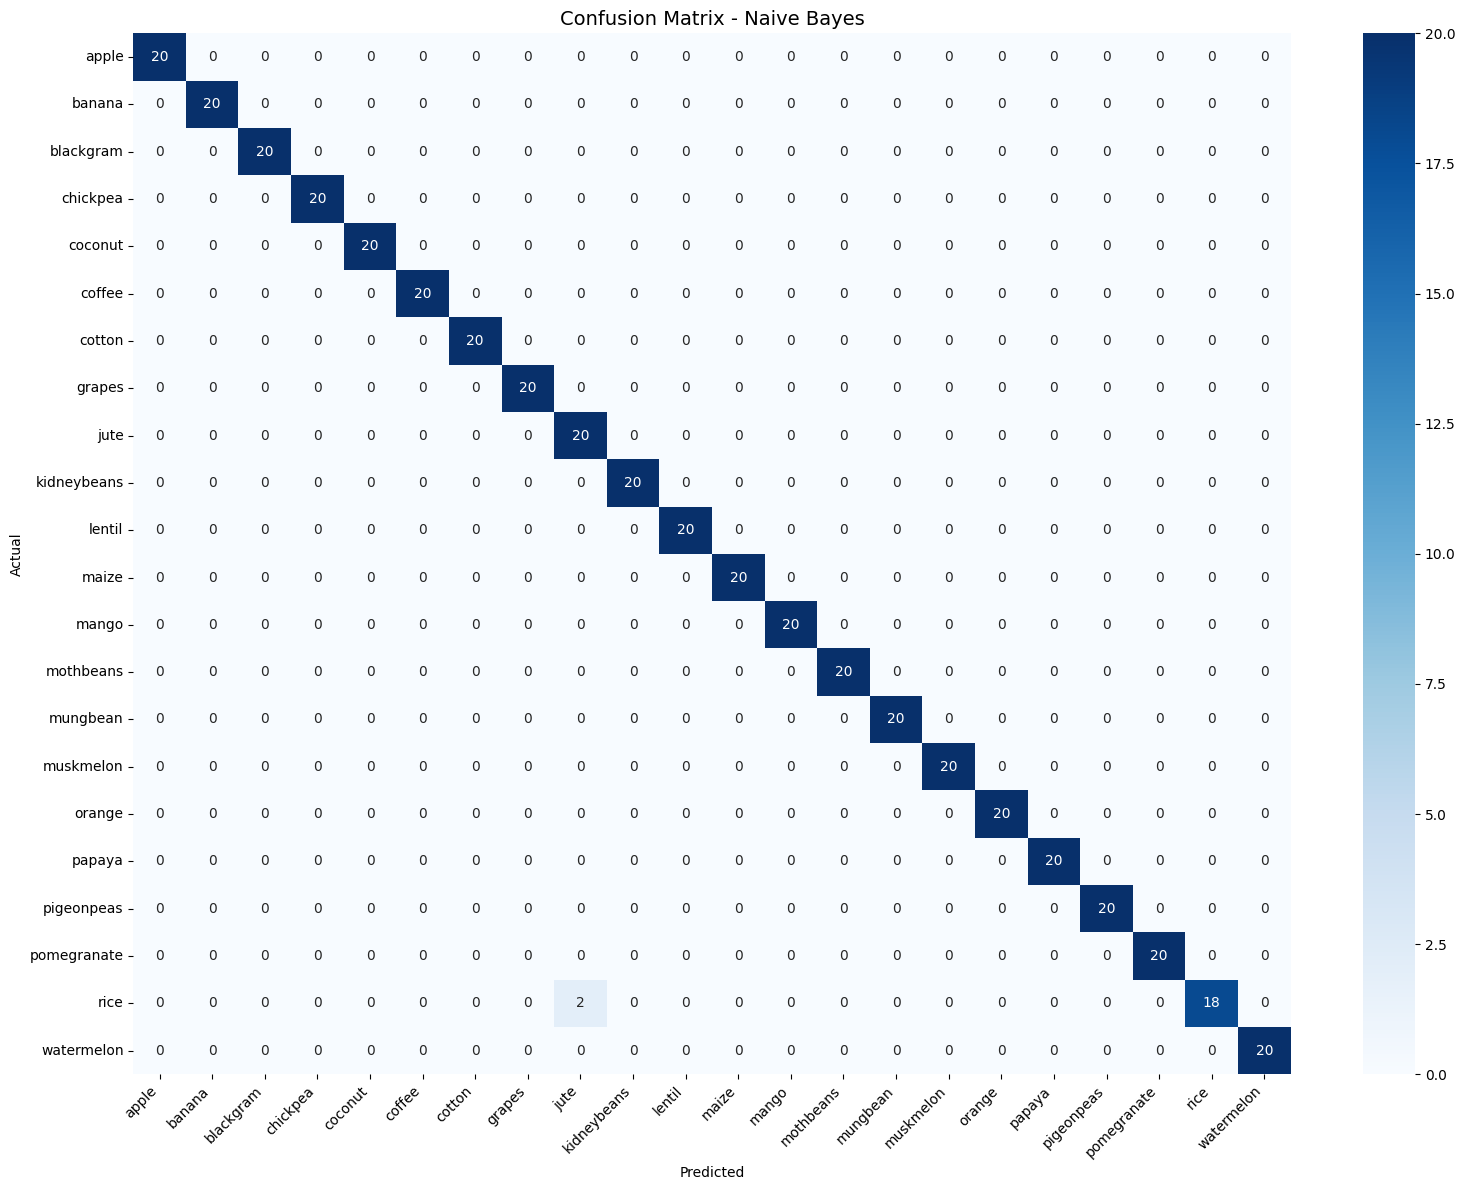

In [33]:
print("=== CONFUSION MATRIX NAIVE BAYES ===")
plt.figure(figsize=(16, 12))
cm_nb = confusion_matrix(y_test_80, nb_tuned_pred)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Naive Bayes', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

=== CONFUSION MATRIX SVM ===


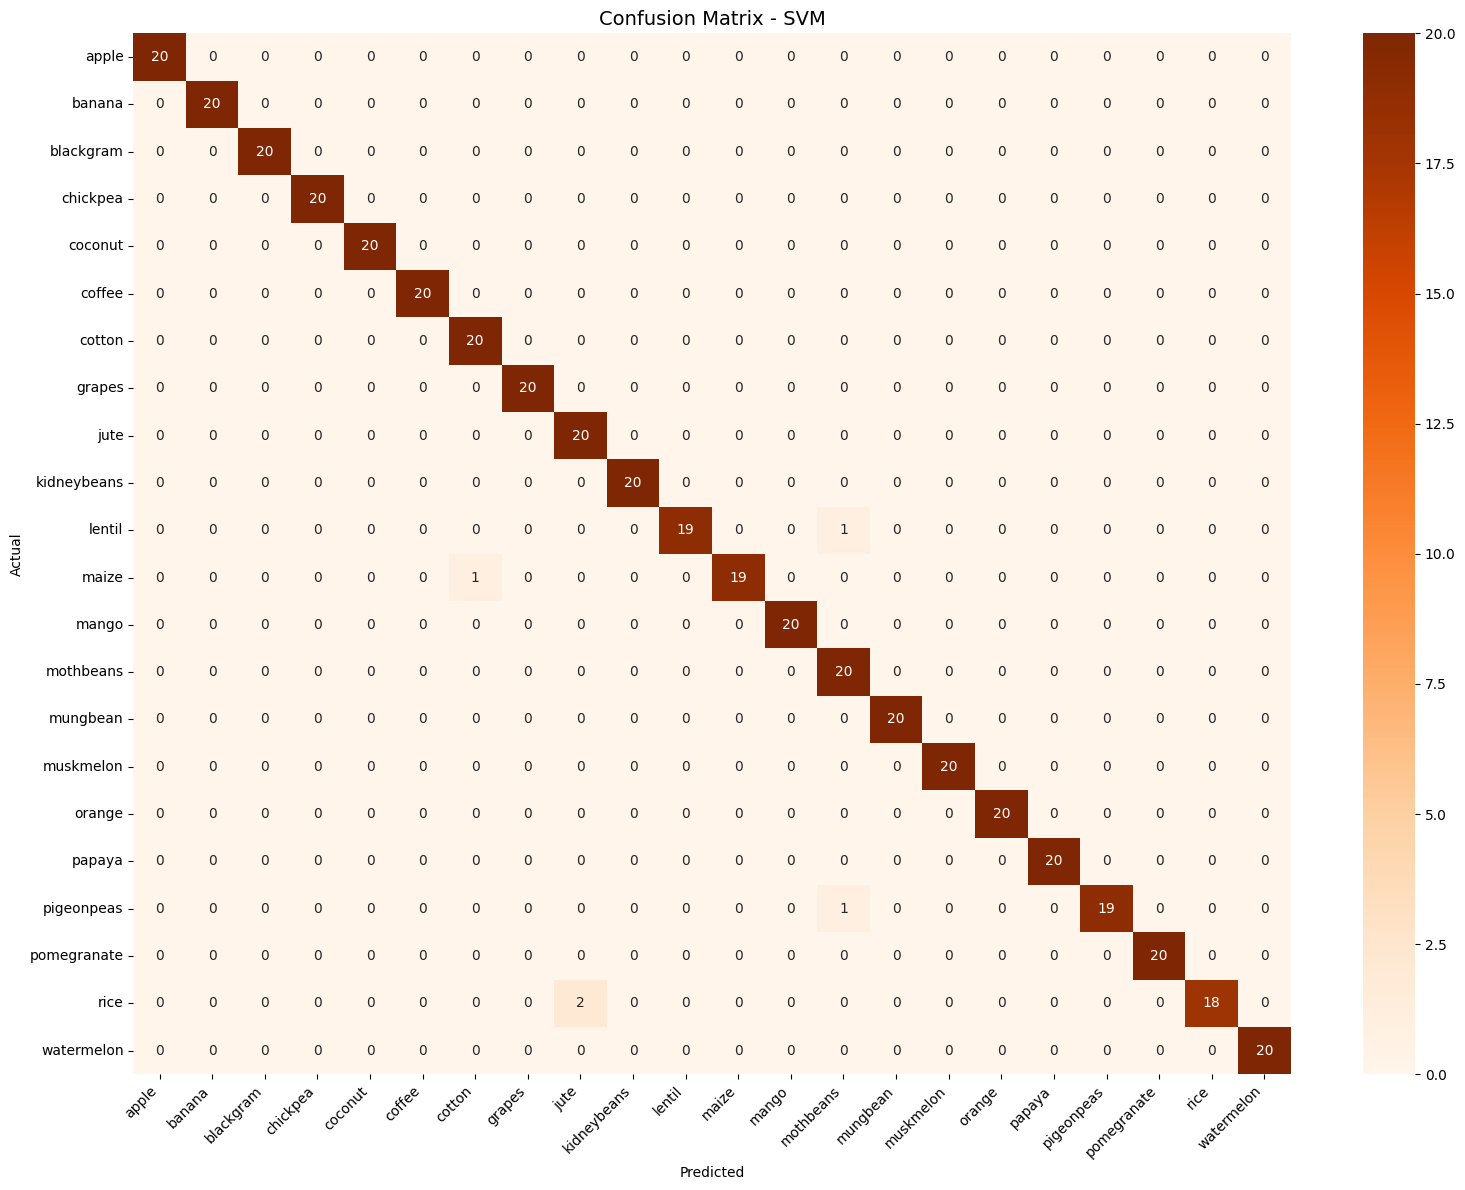

In [34]:
print("=== CONFUSION MATRIX SVM ===")
plt.figure(figsize=(16, 12))
cm_svm = confusion_matrix(y_test_80, svm_tuned_pred)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - SVM', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Model Comparison

In [35]:
print("=== TABEL PERBANDINGAN MODEL ===")

comparison_data = {
    'Algoritma': ['Random Forest', 'Naive Bayes', 'SVM'],
    'Split 70:30': [
        accuracy_score(y_test_70, results_70['RF'][1])*100,
        accuracy_score(y_test_70, results_70['NB'][1])*100,
        accuracy_score(y_test_70, results_70['SVM'][1])*100
    ],
    'Split 80:20': [
        accuracy_score(y_test_80, results_80['RF'][1])*100,
        accuracy_score(y_test_80, results_80['NB'][1])*100,
        accuracy_score(y_test_80, results_80['SVM'][1])*100
    ],
    'Split 90:10': [
        accuracy_score(y_test_90, results_90['RF'][1])*100,
        accuracy_score(y_test_90, results_90['NB'][1])*100,
        accuracy_score(y_test_90, results_90['SVM'][1])*100
    ],
    'Setelah Tuning (80:20)': [
        rf_tuned_acc*100,
        nb_tuned_acc*100,
        svm_tuned_acc*100
    ]
}

df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.round(2)
print(df_comparison.to_string(index=False))

=== TABEL PERBANDINGAN MODEL ===
    Algoritma  Split 70:30  Split 80:20  Split 90:10  Setelah Tuning (80:20)
Random Forest        99.39        99.55        99.09                   99.55
  Naive Bayes        99.24        99.55        99.55                   99.55
          SVM        98.94        98.41        99.55                   98.86


=== GRAFIK PERBANDINGAN AKURASI ===


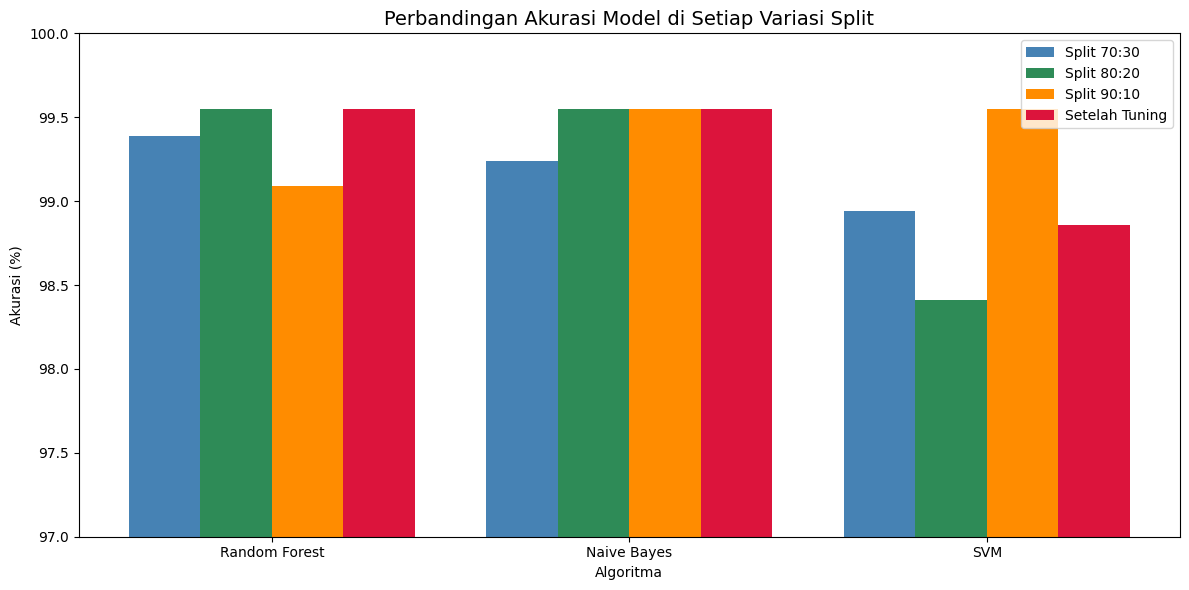

In [36]:
print("=== GRAFIK PERBANDINGAN AKURASI ===")

x = ['Random Forest', 'Naive Bayes', 'SVM']
split_70 = df_comparison['Split 70:30'].tolist()
split_80 = df_comparison['Split 80:20'].tolist()
split_90 = df_comparison['Split 90:10'].tolist()
after_tuning = df_comparison['Setelah Tuning (80:20)'].tolist()

x_pos = np.arange(len(x))
width = 0.2

plt.figure(figsize=(12, 6))
plt.bar(x_pos - 1.5*width, split_70, width, label='Split 70:30', color='steelblue')
plt.bar(x_pos - 0.5*width, split_80, width, label='Split 80:20', color='seagreen')
plt.bar(x_pos + 0.5*width, split_90, width, label='Split 90:10', color='darkorange')
plt.bar(x_pos + 1.5*width, after_tuning, width, label='Setelah Tuning', color='crimson')

plt.xlabel('Algoritma')
plt.ylabel('Akurasi (%)')
plt.title('Perbandingan Akurasi Model di Setiap Variasi Split', fontsize=14)
plt.xticks(x_pos, x)
plt.ylim(97, 100)
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
print("=== KESIMPULAN MODEL TERBAIK ===")

best_model_name = df_comparison.loc[
    df_comparison['Setelah Tuning (80:20)'].idxmax(), 'Algoritma']
best_acc = df_comparison['Setelah Tuning (80:20)'].max()

print(f"Model terbaik    : {best_model_name}")
print(f"Akurasi tertinggi: {best_acc:.2f}%")
print(f"\nSemua model memenuhi ketentuan tugas:")
print(f"✅ Minimal 1 algoritma ≥ 95% → {best_model_name} ({best_acc:.2f}%)")
print(f"✅ Minimal 2 algoritma ≥ 85% → Semua algoritma di atas 98%")

=== KESIMPULAN MODEL TERBAIK ===
Model terbaik    : Random Forest
Akurasi tertinggi: 99.55%

Semua model memenuhi ketentuan tugas:
✅ Minimal 1 algoritma ≥ 95% → Random Forest (99.55%)
✅ Minimal 2 algoritma ≥ 85% → Semua algoritma di atas 98%


# Demo Prediksi

In [40]:
print("=== DEMO PREDIKSI ===")

data_baru = pd.DataFrame({
    'N': [101],
    'P': [29],
    'K': [30],
    'temperature': [25.5],
    'humidity': [58.0],
    'ph': [6.8],
    'rainfall': [150]
})

data_baru_scaled = scaler_80.transform(data_baru)

rf_hasil = le.inverse_transform(rf_tuned.predict(data_baru_scaled))[0]
nb_hasil = le.inverse_transform(nb_tuned.predict(data_baru_scaled))[0]
svm_hasil = le.inverse_transform(svm_tuned.predict(data_baru_scaled))[0]

print("Input kondisi lahan:")
print(f"  Nitrogen     : 101")
print(f"  Fosfor       : 29")
print(f"  Kalium       : 30")
print(f"  Suhu         : 25.5°C")
print(f"  Kelembapan   : 58.0%")
print(f"  pH           : 6.8")
print(f"  Curah Hujan  : 150.0mm")
print(f"\nHasil Prediksi:")
print(f"  Random Forest : {rf_hasil} ")
print(f"  Naive Bayes   : {nb_hasil} ")
print(f"  SVM           : {svm_hasil} ")

=== DEMO PREDIKSI ===
Input kondisi lahan:
  Nitrogen     : 101
  Fosfor       : 29
  Kalium       : 30
  Suhu         : 25.5°C
  Kelembapan   : 58.0%
  pH           : 6.8
  Curah Hujan  : 150.0mm

Hasil Prediksi:
  Random Forest : coffee 
  Naive Bayes   : coffee 
  SVM           : coffee 


In [38]:
print("=" * 50)
print("RINGKASAN AKHIR NOTEBOOK")
print("=" * 50)
print(f"\nJudul   : Analisis Perbandingan Algoritma Random Forest,")
print(f"          Naive Bayes, dan Support Vector Machine untuk")
print(f"          Klasifikasi Rekomendasi Tanaman Berdasarkan")
print(f"          Kondisi Tanah dan Iklim")
print(f"\nDataset : Crop Recommendation Dataset")
print(f"          2200 baris | 7 fitur | 22 kelas tanaman")
print(f"\n{'='*50}")
print(f"HASIL AKURASI SETELAH TUNING (Split 80:20):")
print(f"{'='*50}")
print(f"  Random Forest : {rf_tuned_acc*100:.2f}% ✅")
print(f"  Naive Bayes   : {nb_tuned_acc*100:.2f}% ✅")
print(f"  SVM           : {svm_tuned_acc*100:.2f}% ✅")
print(f"\n{'='*50}")
print(f"KESIMPULAN:")
print(f"{'='*50}")
print(f"  ✅ Semua algoritma memenuhi target akurasi ≥ 95%")
print(f"  ✅ Hyperparameter tuning berhasil dilakukan")
print(f"  ✅ 3 variasi data splitting berhasil diuji")
print(f"  ✅ Model siap digunakan untuk prediksi lahan baru")
print(f"\n{'='*50}")
print(f"NOTEBOOK SELESAI! 🎉")
print(f"{'='*50}")

RINGKASAN AKHIR NOTEBOOK

Judul   : Analisis Perbandingan Algoritma Random Forest,
          Naive Bayes, dan Support Vector Machine untuk
          Klasifikasi Rekomendasi Tanaman Berdasarkan
          Kondisi Tanah dan Iklim

Dataset : Crop Recommendation Dataset
          2200 baris | 7 fitur | 22 kelas tanaman

HASIL AKURASI SETELAH TUNING (Split 80:20):
  Random Forest : 99.55% ✅
  Naive Bayes   : 99.55% ✅
  SVM           : 98.86% ✅

KESIMPULAN:
  ✅ Semua algoritma memenuhi target akurasi ≥ 95%
  ✅ Hyperparameter tuning berhasil dilakukan
  ✅ 3 variasi data splitting berhasil diuji
  ✅ Model siap digunakan untuk prediksi lahan baru

NOTEBOOK SELESAI! 🎉
